# Example of autoscaling problem

In [1]:
# Basic imports
from numpy import mean
from ascal import AscalConfig, Ascal
from examples import aws_eu_west_1_c5m5r5

In [2]:
# Configuration file defining ASCAL problem
config_file = "config.yaml"
log_file = "config.log" # Log file

In [3]:
# Read the problem configuration file and validate it
# Note that it is possible to validate any ASCAL configuration with method AscalConfig.validate_config()
ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)

# Create the autoscaling problem
ascal_problem = Ascal(ascal_config, log=log_file)

# Last time that can be simulated (last time in the trace)
# Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
last_time = ascal_problem.last_time 
print(f'Time range of the simulation: 0 - {last_time} seconds')

# Run the autoscaling problem until the end. The argument of run() method is the last simulation time in seconds
# Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
ascal_problem.run()

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
Time: 2500 s
Time: 2600 s
Time: 2700 s
Time: 2800 s
Time: 2900 s
Time: 3000 s
Time: 3100 s
Time: 3200 s
Time: 3300 s
Time: 3400 s
Time: 3500 s
Time: 3600 s
Time: 3700 s
Time: 3800 s
Time: 3900 s
Time: 4000 s
Time: 4100 s
Time: 4200 s
Time: 4300 s
Time: 4400 s
Time: 4500 s
Time: 4600 s
Time: 4700 s
Time: 4800 s
Time: 4900 s
Time: 5000 s
Time: 5100 s
Time: 5200 s
Time: 5300 s
Time: 5400 s
Time: 5500 s
Time: 5600 s
Time: 5700 s
Time: 5800 s
Time: 5900 s
Time: 6000 s
Time: 6100 s
Time: 6200 s
Time: 6300 s
Time: 6400 s
Time: 6500 s
Time: 6600 s
Time: 6700 s
Time: 6800 s
Time: 6900 s
Time: 7000 s
Time: 7100 s
Time: 7200 s
Time: 7300 s
Ti

In [4]:
# Write workloads, performance and cost into csv files. Each line in the csv files corresponds to 1 second
ascal_problem.write_workload_csv('workloads.csv')
ascal_problem.write_performance_csv('performances.csv')
ascal_problem.write_cost_csv('cost.csv')

In [5]:
# Write allocations in a YAML file
ascal_problem.write_allocations('allocations.yaml')

In [6]:
# Get application overloads as workload/performance
workloads = ascal_problem.get_workloads()
performances = ascal_problem.get_performances()
overloads = {app: [w/p for w, p in zip(workloads[app], performances[app])] for app in workloads}

In [7]:
# Get queue waiting times relative to service times, assuming each container is a server in a 
# heterogenous D/D/m queue
queue_waiting_times = ascal_problem.get_queue_waiting_times()
avgs = {
    app_name: mean(waiting_times)
    for app_name, waiting_times in queue_waiting_times.items()
}
for app_name in dict(queue_waiting_times):
    queue_waiting_times[f"{app_name} QoS = {avgs[app_name]:.3f}"] = queue_waiting_times.pop(app_name)

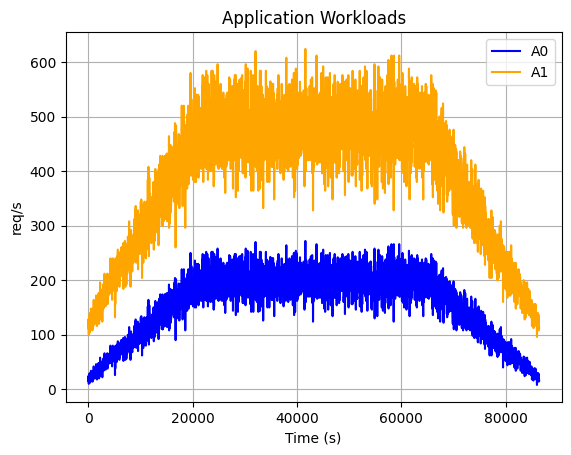

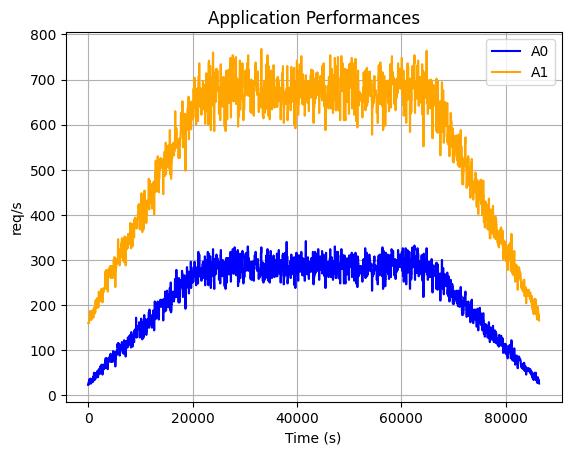

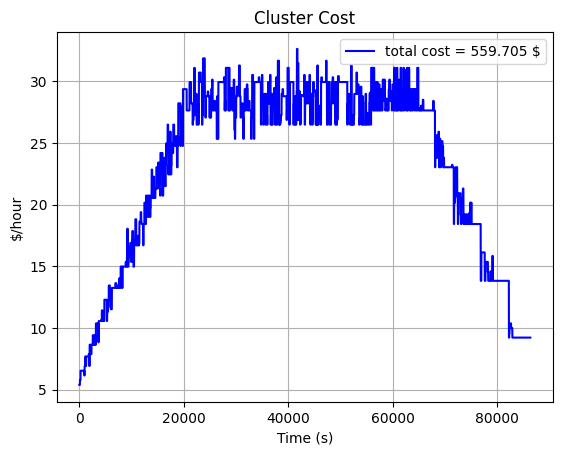

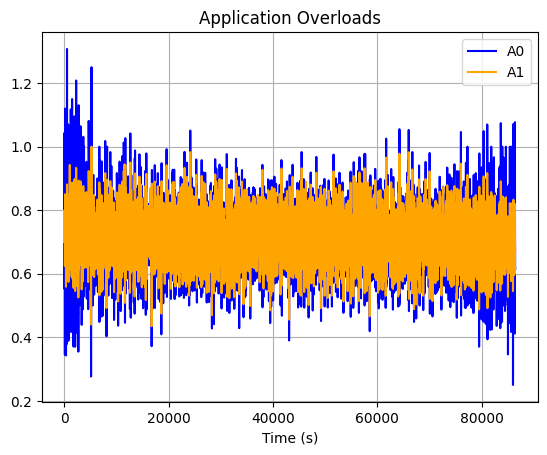

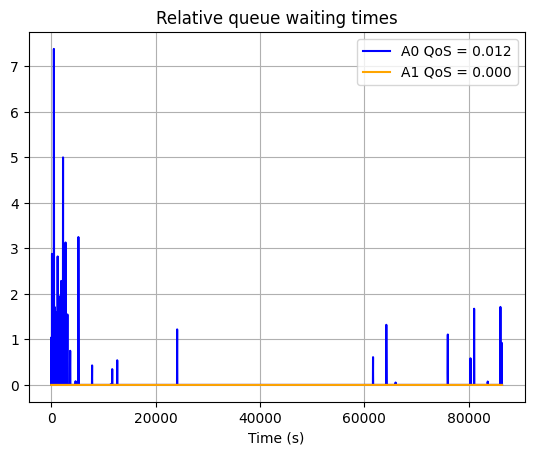

In [8]:
# Plot autoscaling information
ascal_problem.plot(ascal_problem.get_workloads(), "Application Workloads", "req/s")
ascal_problem.plot(ascal_problem.get_performances(), "Application Performances", "req/s")
cluster_cost = ascal_problem.get_cluster_cost()
total_cost_str = f"total cost = {sum(cluster_cost)/3600:.3f} $"
ascal_problem.plot({total_cost_str: cluster_cost}, "Cluster Cost", "$/hour")
ascal_problem.plot(overloads, "Application Overloads")
ascal_problem.plot(queue_waiting_times, "Relative queue waiting times")

In [9]:
# Useful properties
last_time = ascal_problem.last_time # Last time that can be simulated
current_time =  ascal_problem.time # Current simulated time in range [0, last_time]
billing_changes = ascal_problem.billing_changes # Dictionary with times and cluster state on billing changes
performance_changes = ascal_problem.performance_changes # Dictionary with times and cluster state on allocation changes
calculation_times = ascal_problem.calc_times # Calculation times to obtain new allocations

In [10]:
# Recycling levels for Horizontal/Vertical autoscalers
node_recycling_levels, container_recycling_levels = ascal_problem.get_recycling_levels()

/home/chechu/ascal/ascal/ascal.py:717: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


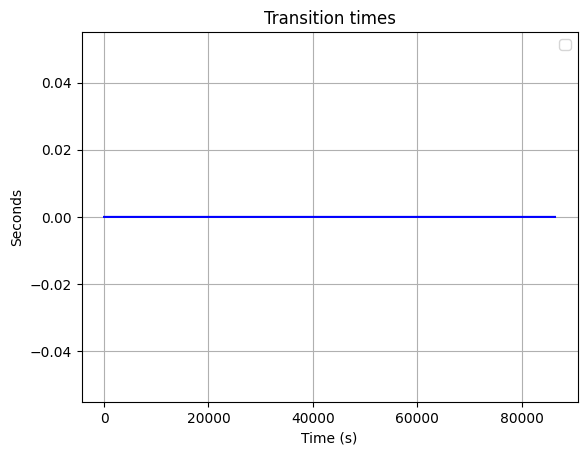

In [11]:
# Plot times to calculate transitions
transition_times = calculation_times["transition_times"]
ascal_problem.plot({'_nolegend_': transition_times}, "Transition times", "Seconds")

/home/chechu/ascal/ascal/ascal.py:762: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


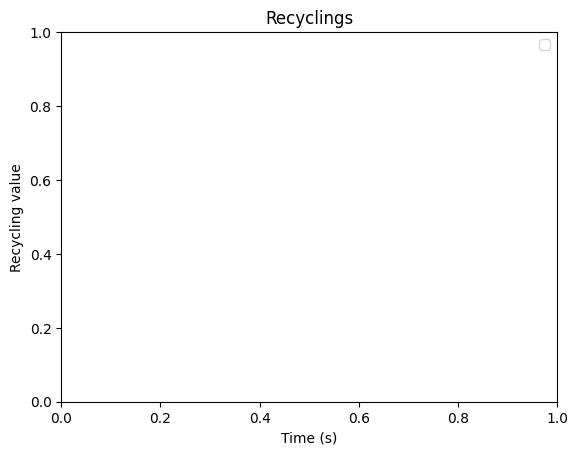

In [12]:
# Plot recyclings
ascal_problem.plot_bar({'nodes': node_recycling_levels, 'containers': container_recycling_levels},
                   "Recyclings", "Recycling value")